In [1]:
import json

In [2]:
import pickle

In [3]:
import pandas as pd

In [4]:
with open("preds_wo_features_scores.pkl", "rb") as f:
    preds_wo_features_scores = pickle.load(f)

In [5]:
preds_wo_features_scores.head()

,user_name,item_title,shared_tags,is_valid,explanation
0,ai_and_nlp_developer,Цифровой универсальный комментарий,0.250000,1,The recommendation is valid in terms of semant...
1,ai_and_nlp_developer,"Учебный ассистент по курсу "" Бухгалтерский учет""",0.000000,1,"The project 'Учебный ассистент по курсу ""Бухга..."
2,ai_and_nlp_developer,Мультиагентная интеллектуальная обучающая сист...,0.400000,1,The project is valid in terms of semantic rele...
3,ai_and_nlp_developer,Разработка чат-бота для выбора пептидов для се...,0.333333,1,The recommendation is valid in terms of semant...
4,ai_and_nlp_developer,Интеллектуальный помощник по обработке лекций ...,0.166667,1,The project is highly relevant to the student'...


In [6]:
with open("preds_w_features_scores.pkl", "rb") as f:
    preds_w_features_scores = pickle.load(f)

In [7]:
for k, v in preds_w_features_scores[preds_w_features_scores["is_valid"] == 1].sample(n=1).to_dict(orient="records")[0].items():
    print(f"{k}: {v}")

user_name: geopolitics_and_international_relations_expert
item_title: Влияние США, Турции, европейских и ближневосточных государств на энергетические отношения России и Китая со странами Центральной Азии.
shared_tags: 0.5
is_valid: 1
explanation: The project is highly relevant to the student's bio and interests. It aligns with key areas such as geopolitics, energy security, international relations, and regional studies, particularly focusing on the dynamics between major global powers and energy relations in Central Asia. The tags intersect significantly with the student's interests, including 'geopolitics', 'energy_security', 'international_relations', and 'regional_studies', making it a semantically and thematically appropriate recommendation.


In [8]:
for k, v in preds_w_features_scores[preds_w_features_scores["is_valid"] == 0].sample(n=1).to_dict(orient="records")[0].items():
    print(f"{k}: {v}")

user_name: educational_psychologist_and_methodologist
item_title: Разработка инструмента на основе искусственного интеллекта для оценки регуляторных рисков
shared_tags: 0.0
is_valid: 0
explanation: The project focuses on artificial intelligence and financial risk assessment, which are not aligned with the student's interests in educational psychology, instructional design, learning theory, cognitive science, student support, and edtech. There is no semantic or thematic overlap with the student's bio or interests.


In [9]:
preds_w_features_scores.head()

,user_name,item_title,shared_tags,is_valid,explanation
0,ai_and_nlp_developer,Цифровой универсальный комментарий,0.250000,1,The project 'Цифровой универсальный комментари...
1,ai_and_nlp_developer,Мультиагентная интеллектуальная обучающая сист...,0.400000,1,The project is valid in terms of semantic rele...
2,ai_and_nlp_developer,"Учебный ассистент по курсу "" Бухгалтерский учет""",0.000000,1,"The project 'Учебный ассистент по курсу ""Бухга..."
3,ai_and_nlp_developer,Разработка чат-бота для выбора пептидов для се...,0.333333,1,The project aligns well with the student's int...
4,ai_and_nlp_developer,Разработка MVP платформы для ИИ-персонализации...,0.166667,1,The project is valid in terms of semantic rele...


In [10]:
pwofg = (
    preds_wo_features_scores.groupby(by=["user_name"])
    .agg({"is_valid": "mean"})
    .reset_index(drop=False)
)
pwofg.columns = ["user_name", "mean_score"]
pwofg = pwofg.sort_values(by=["mean_score"], ascending=False).reset_index(drop=True)

In [11]:
pwofg.head()

,user_name,mean_score
0,strategic_management_consultant_and_leader,1.0
1,regional_studies_and_geopolitics_expert,1.0
2,media_and_communications_specialist,1.0
3,media_and_communication_strategist,1.0
4,international_relations_and_geopolitics_expert,1.0


In [12]:
pwfg = (
    preds_w_features_scores.groupby(by=["user_name"])
    .agg({"is_valid": "mean"})
    .reset_index(drop=False)
)
pwfg.columns = ["user_name", "mean_score"]
pwfg = pwfg.sort_values(by=["mean_score"], ascending=False).reset_index(drop=True)

In [13]:
pwfg.head()

,user_name,mean_score
0,geopolitics_and_international_relations_expert,1.0
1,multilingual_nlp_and_ai_specialist,1.0
2,media_journalism_and_cultural_studies_expert,1.0
3,media_and_culture_strategist,1.0
4,media_and_communications_specialist,1.0


In [14]:
final = pwofg.merge(pwfg, on=["user_name"])
final["diff"] = final["mean_score_y"] - final["mean_score_x"]

In [15]:
final.to_excel("llm_as_a_judge.xlsx", index=False)

In [16]:
with open("artificial_profiles_scores.pkl", "rb") as f:
    artificial_profiles_scores = pickle.load(f)

In [17]:
with open("titles_with_tags_dict.pkl", "rb") as f:
    titles_with_tags_dict = pickle.load(f)

In [18]:
data = []

for profile_name, scores in artificial_profiles_scores.items():
    for title, score in scores.items():
        title = json.loads(title)["title"]
        tags = titles_with_tags_dict.get(title, [])
        data.append(
            {
                "profile_name": profile_name,
                "title": title,
                "score": score,
                "tags": tags,
            }
        )

df = pd.DataFrame(data)

In [19]:
df.head()

,profile_name,title,score,tags
0,global_economics_and_geopolitics_analyst,Исследование приоритетов и механизмов реализац...,5,"[international_relations, political_economics,..."
1,global_economics_and_geopolitics_analyst,Сеть военно-политических союзов в Евразии: баз...,4,"[geopolitics, international_relations, databas..."
2,global_economics_and_geopolitics_analyst,Ежемесячный мониторинг мировой экономики и гео...,5,"[economics, geopolitics, risk_management, macr..."
3,global_economics_and_geopolitics_analyst,Запуск регулярного подкаста НИУ ВШЭ о странах ...,2,"[media_production, podcast, international_rela..."
4,global_economics_and_geopolitics_analyst,"Студенческий клуб ""Говорим об Эфиопии""",3,"[sociology, international_relations, culture, ..."


In [20]:
df_exploded = df.explode("tags").reset_index(drop=True)

In [21]:
sorted(df_exploded.profile_name.unique())

['ai_and_nlp_developer',
 'ai_policy_and_social_impact_analyst',
 'cultural_and_media_anthropologist',
 'cultural_humanities_researcher_media_studies',
 'data_driven_policy_analyst',
 'digital_marketing_and_media_strategy',
 'digital_platform_developer_and_educator',
 'education_and_cultural_development_expert',
 'educational_psychologist_and_methodologist',
 'educational_tech_developer',
 'financial_economist_and_analyst',
 'geopolitics_and_international_relations_expert',
 'global_economics_and_geopolitics_analyst',
 'historical_culture_researcher_media_specialist',
 'international_relations_and_geopolitics_expert',
 'legal_policy_and_ethics_researcher',
 'literary_and_cultural_analyst_cross_cultural',
 'media_and_communication_strategist',
 'media_and_communications_specialist',
 'media_and_culture_strategist',
 'media_journalism_and_cultural_studies_expert',
 'multidisciplinary_tech_and_language_developer',
 'multilingual_linguistics_researcher',
 'multilingual_nlp_and_ai_specialis

In [22]:
import squarify
from matplotlib import pyplot as plt
import seaborn as sns

<Axes: xlabel='score', ylabel='profile_name'>

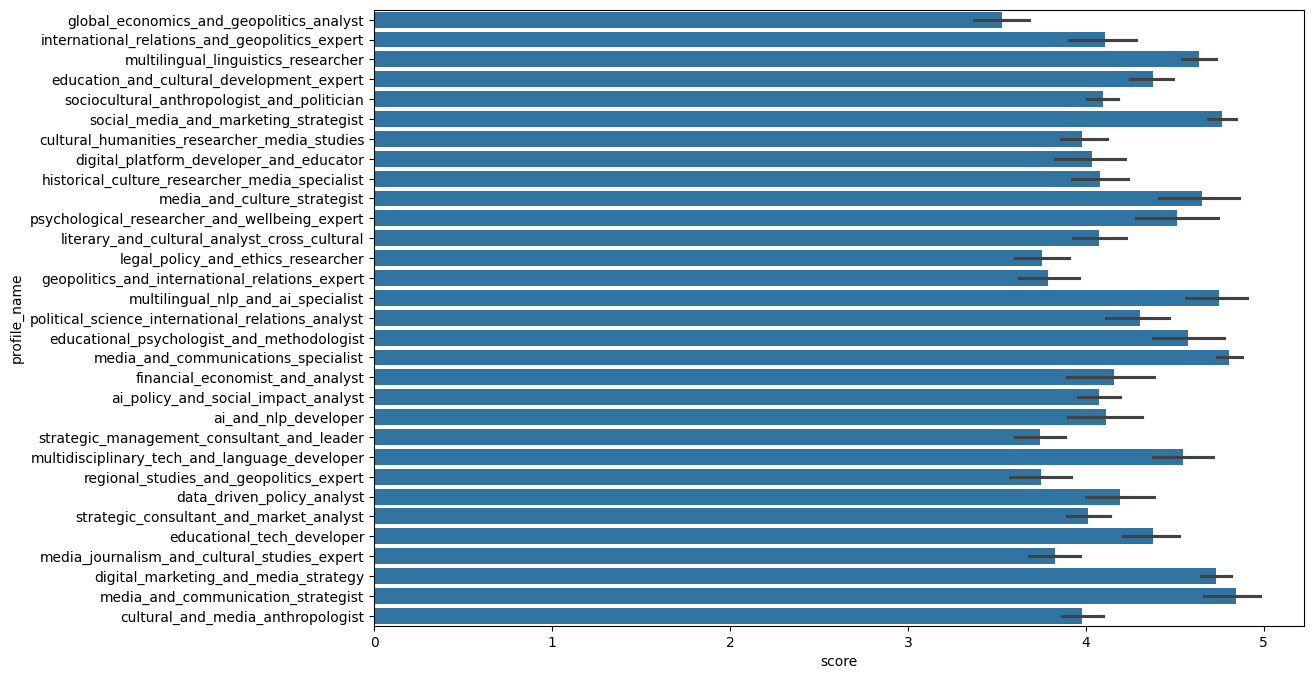

In [23]:
fig = plt.figure(figsize=(12, 8))

sns.barplot(data=df, x="score", y="profile_name", orient="h")

In [24]:
df_score = df_exploded.groupby(by=["profile_name"]).agg({"score": "median"}).reset_index(drop=False)
df_score.columns = ["profile_name", "score"]
df_score = df_score.sort_values(by=["score"], ascending=False).reset_index(drop=True)

<Axes: xlabel='score', ylabel='profile_name'>

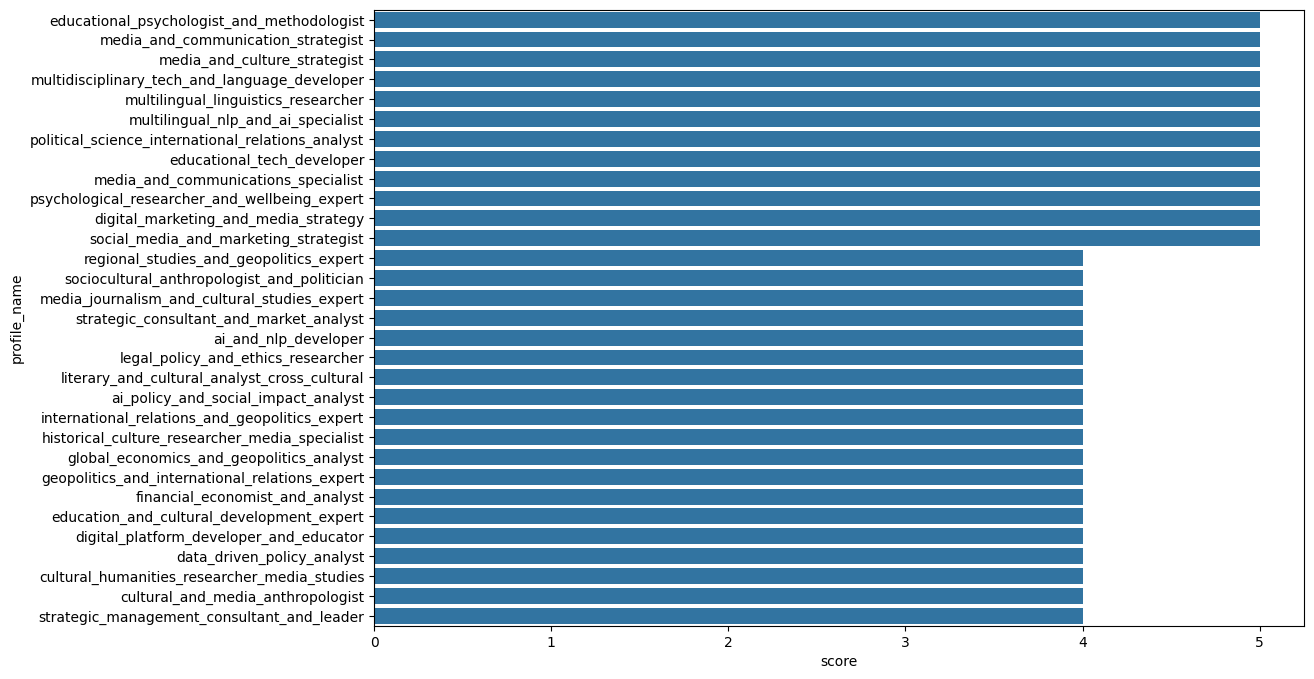

In [25]:
fig = plt.figure(figsize=(12, 8))

sns.barplot(data=df_score, x="score", y="profile_name", orient="h")

In [26]:
df_exploded_tags = df_exploded[(df_exploded["profile_name"] == "global_economics_and_geopolitics_analyst") & (df_exploded["score"] == 5)].groupby(by=["tags"]).agg({"score": ["count", "median"]}).reset_index(drop=False)
df_exploded_tags.columns = ["tags", "count", "score"]
df_exploded_tags = df_exploded_tags.sort_values(by=["count"], ascending=False).reset_index(drop=True)
df_exploded_tags = df_exploded_tags[df_exploded_tags["count"] > 1].reset_index(drop=True)

In [27]:
df_exploded_tags.head()

,tags,count,score
0,geopolitics,27,5.0
1,international_relations,23,5.0
2,economics,19,5.0
3,political_science,9,5.0
4,regional_studies,6,5.0


In [28]:
df_exploded_tags.tail()

,tags,count,score
30,time_series,2,5.0
31,bilateral_relations,2,5.0
32,brics,2,5.0
33,technology_sector,2,5.0
34,data_analysis,2,5.0


<Axes: >

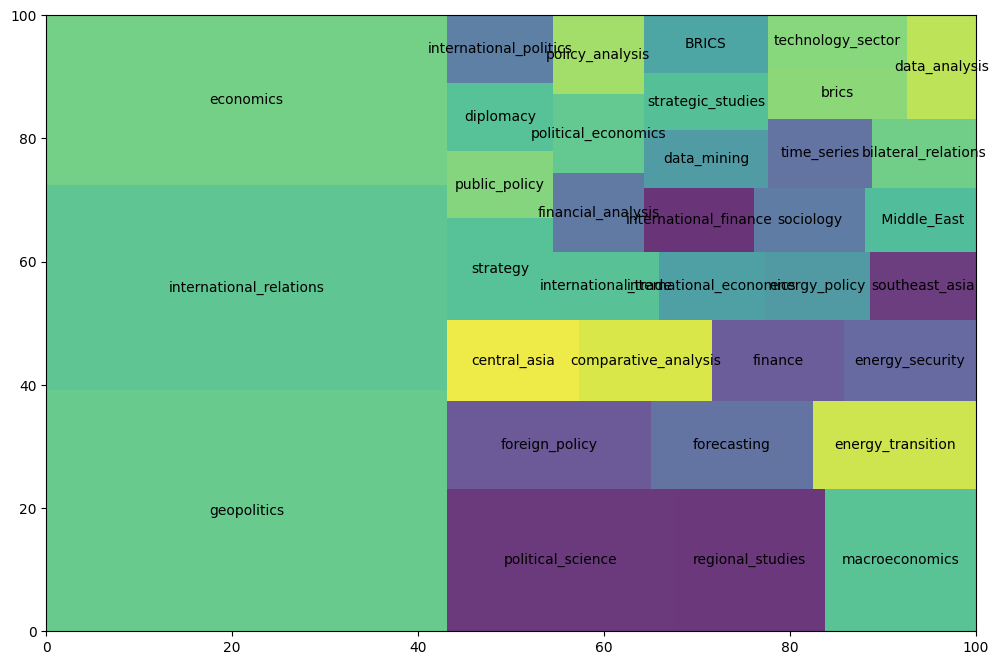

In [29]:
fig = plt.figure(figsize=(12, 8))

squarify.plot(sizes=df_exploded_tags["count"], label=df_exploded_tags["tags"], alpha=0.8)

In [30]:
df_exploded_profiles = df_exploded[(df_exploded["tags"] == "economics") & (df_exploded["score"] == 5)].groupby(by=["profile_name"]).agg({"score": ["count", "median"]}).reset_index(drop=False)
df_exploded_profiles.columns = ["profile_name", "count", "score"]
df_exploded_profiles = df_exploded_profiles.sort_values(by=["count"], ascending=False).reset_index(drop=True)
df_exploded_profiles = df_exploded_profiles[df_exploded_profiles["count"] > 1].reset_index(drop=True)

In [31]:
df_exploded_profiles.head

<bound method NDFrame.head of                                          profile_name  count  score
0             strategic_consultant_and_market_analyst     32    5.0
1                          data_driven_policy_analyst     24    5.0
2            global_economics_and_geopolitics_analyst     19    5.0
3                     financial_economist_and_analyst     18    5.0
4   political_science_international_relations_analyst     13    5.0
5             regional_studies_and_geopolitics_expert     12    5.0
6         sociocultural_anthropologist_and_politician     11    5.0
7      geopolitics_and_international_relations_expert     11    5.0
8          strategic_management_consultant_and_leader     10    5.0
9      international_relations_and_geopolitics_expert      9    5.0
10                ai_policy_and_social_impact_analyst      5    5.0
11                 legal_policy_and_ethics_researcher      3    5.0
12                  cultural_and_media_anthropologist      2    5.0>

<Axes: >

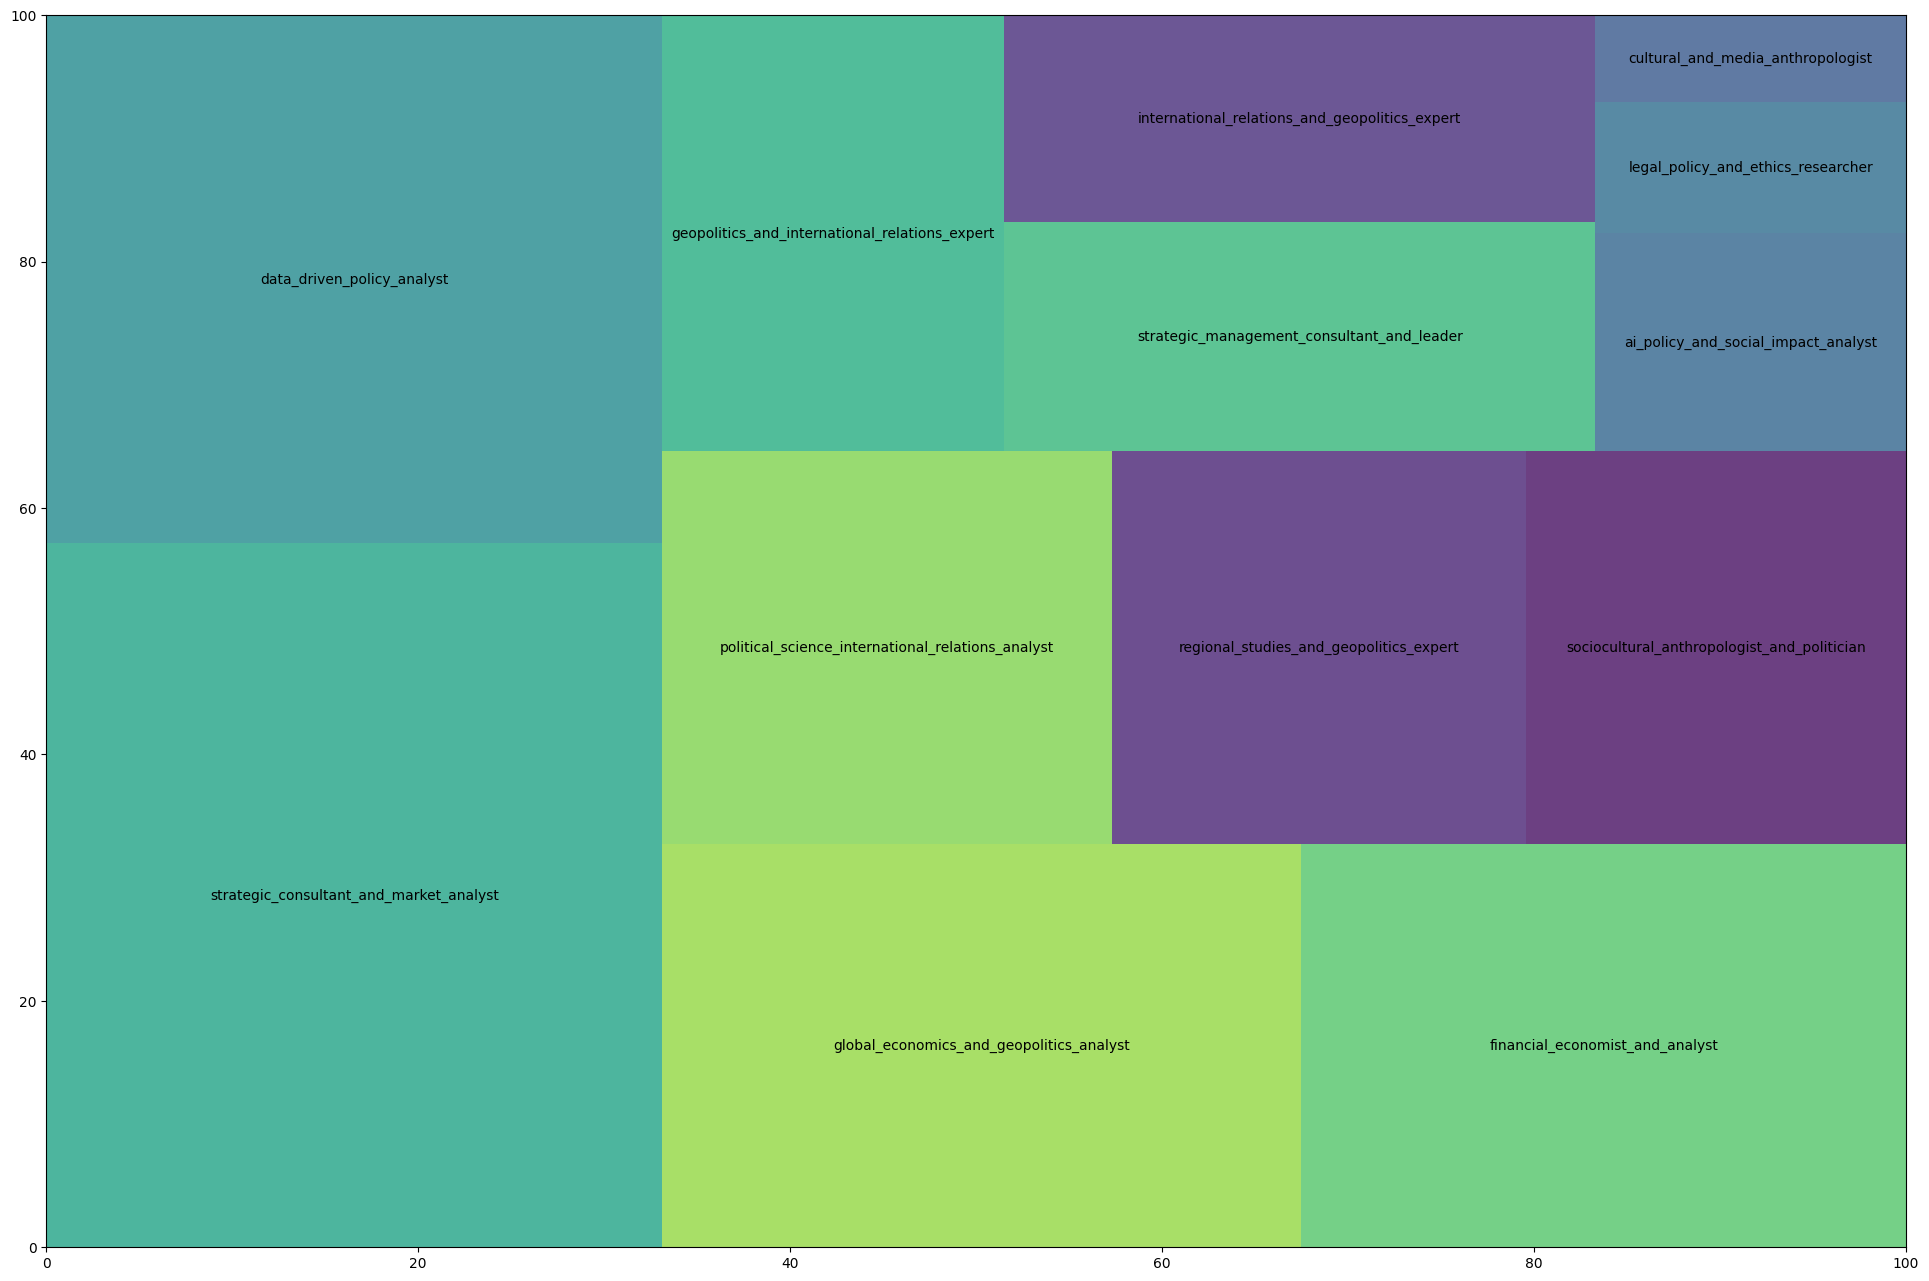

In [32]:
fig = plt.figure(figsize=(24, 16))

squarify.plot(sizes=df_exploded_profiles["count"], label=df_exploded_profiles["profile_name"], alpha=0.8)

In [33]:
data = []

for title in titles_with_tags_dict.keys():
    tags = titles_with_tags_dict[title]
    data.append({"title": title, "tags": tags})

df = pd.DataFrame(data)

In [34]:
df.head()

,title,tags
0,Исследование приоритетов и механизмов реализац...,"[international_relations, political_economics,..."
1,Антрополе - научно-популярный видео-подкаст о ...,"[anthropology, social_phenomena, media, podcas..."
2,"Разработка, создание и ведение сайта, посвящен...","[web_development, history, cultural_studies, d..."
3,Перевод с английского языка коллективной моног...,"[criminology, literature_review, translation, ..."
4,Сеть военно-политических союзов в Евразии: баз...,"[geopolitics, international_relations, databas..."


In [35]:
df = df.explode("tags").reset_index(drop=True)

In [36]:
dfg = df.groupby(by=["tags"]).agg({"title": "count"}).reset_index(drop=False).sort_values(by=["title"], ascending=False).reset_index(drop=True).head(32)

<Axes: >

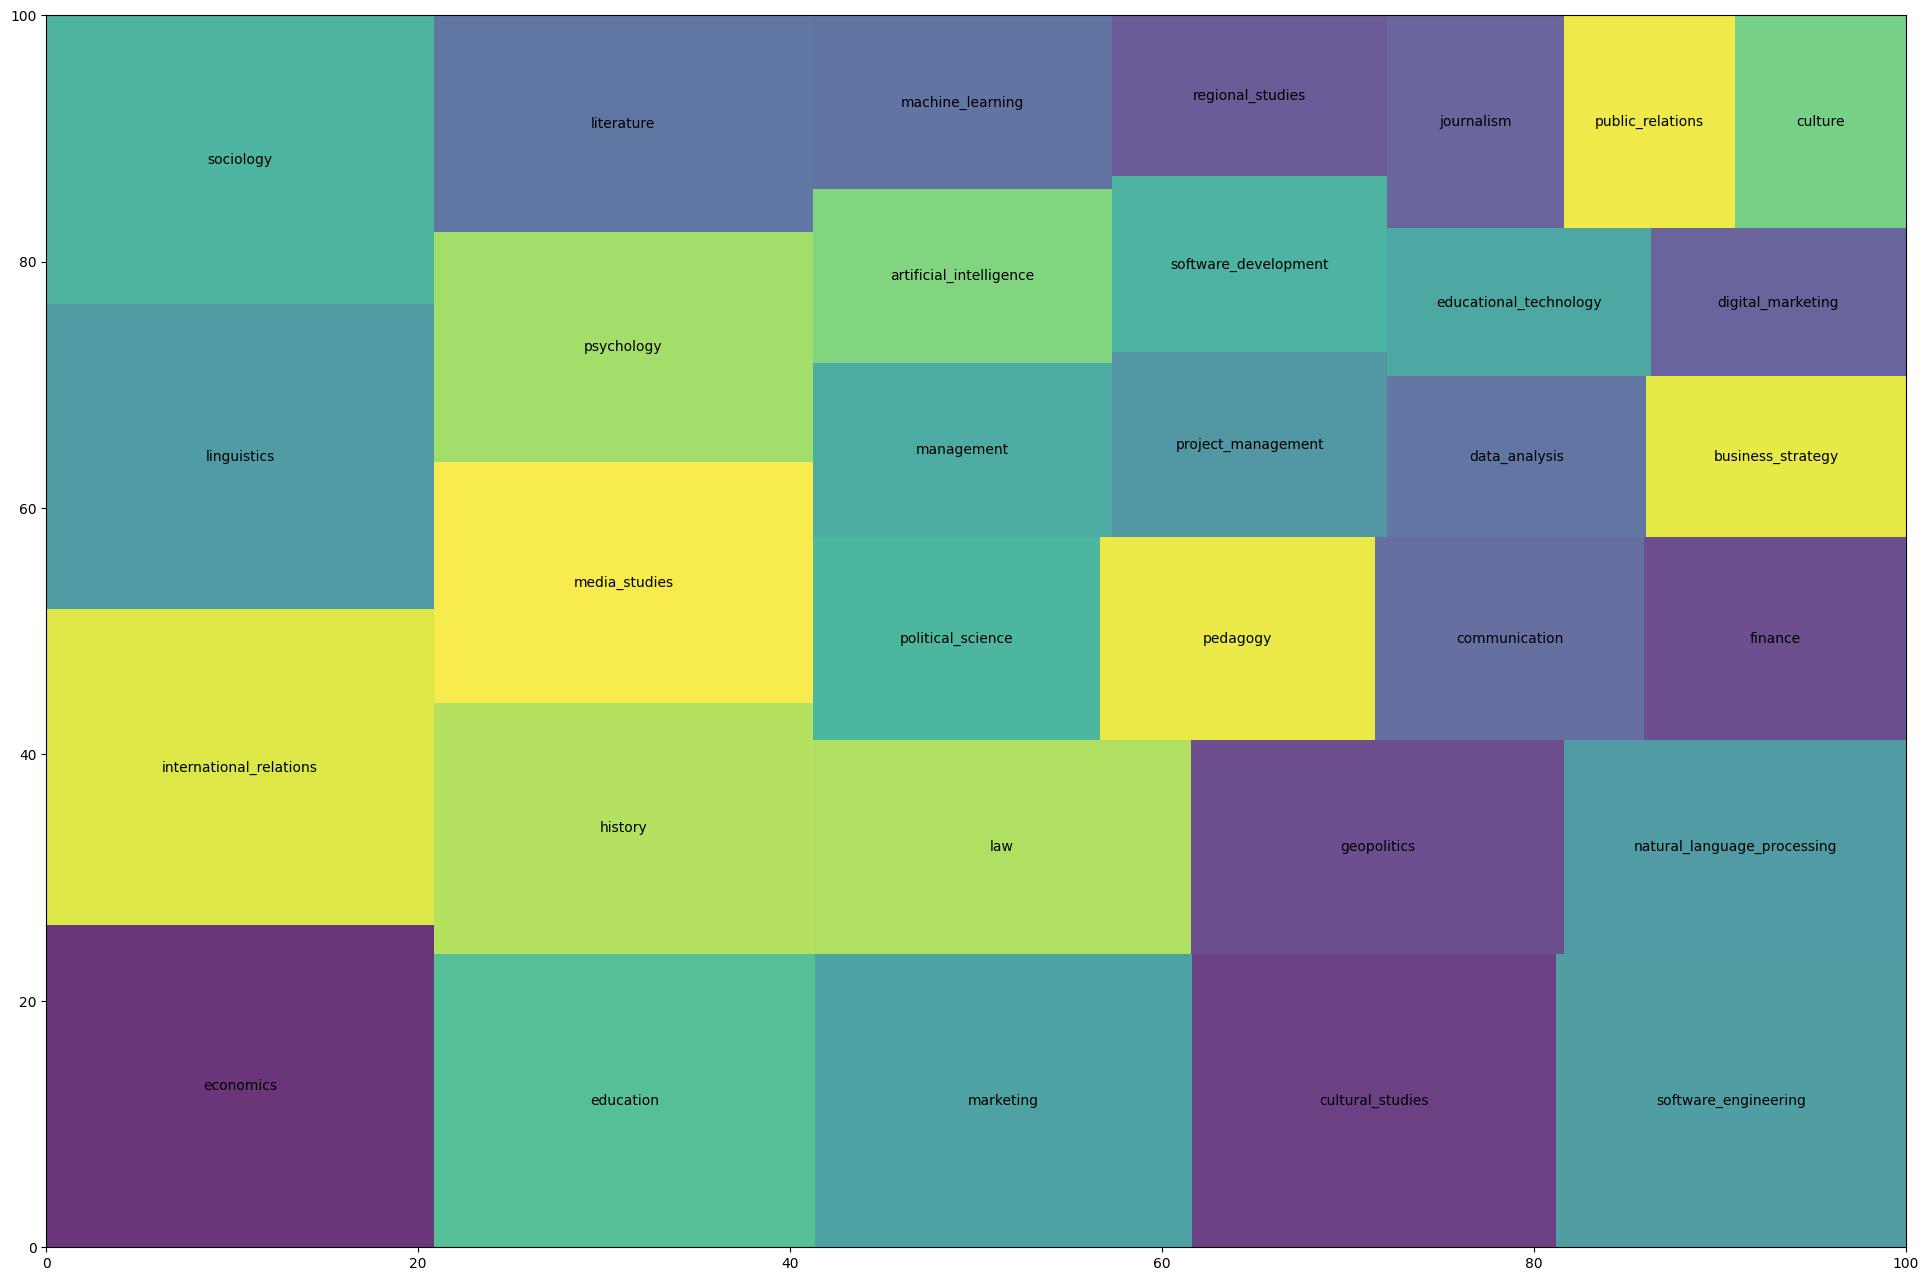

In [37]:
fig = plt.figure(figsize=(24, 16))

squarify.plot(sizes=dfg["title"], label=dfg["tags"], alpha=0.8)

In [38]:
dfg.to_excel("tags_distribution.xlsx", index=False)